# 4.3 Application of Forward Mode Automatic Differentiation 

In [1]:
using CairoMakie
using Distributions
using Random

Define dual number and the corresponding operations

In [2]:
mutable struct Dual <: Number
    v::Float64 #value of the function
    ∂::Float64 #its derivative
end

import Base:+,-,*,sin,^,/,cos
+(a::Dual,b::Dual)=Dual(a.v+b.v,a.∂+b.∂) 
+(a::Dual,b::Number)=Dual(a.v+b,a.∂) 
+(a::Number,b::Dual)=Dual(a+b.v,b.∂) 
-(a::Dual,b::Dual)=Dual(a.v-b.v,a.∂-b.∂) 
-(a::Number,b::Dual)=Dual(a-b.v,-b.∂) 
-(a::Dual,b::Number)=Dual(a.v-b,a.∂) 
*(a::Dual,b::Dual)=Dual(a.v*b.v,a.v*b.∂+b.v*a.∂) 
*(a::Number,b::Dual)=Dual(a*b.v,a*b.∂) 
/(a::Dual,b::Dual)=Dual(a.v/b.v,(b.v*a.∂-a.v*b.∂)/(b.v)^2) 
/(a::Number,b::Dual)=Dual(a/b.v,(-a*b.∂)/(b.v)^2) 
#*(a::Float64,b::Dual)=Dual(a*b.v,a*b.∂) 
^(a::Dual,n::Integer)=Dual(a.v^n,n*a.v^(n-1)*a.∂) 
sin(a::Dual)=Dual(sin(a.v),cos(a.v)*a.∂) 
cos(a::Dual)=Dual(cos(a.v),-sin(a.v)*a.∂) 

cos (generic function with 26 methods)

Now let's do an example where we have to use dual numbers to find derivatives. We will use the same example as we have always done, where we want to find the minimum material needed to make a cylinder to contain 1m$^3$ of water.

$1=\pi r^2 h$

$A(r)=\pi r^2+\pi r^2+2\pi r h$

$A(r)=2\pi r^2+\frac{2}{r}$

$f(r)=dA(r)/dr=4\pi r-\frac{2}{r^2}=0$

We want to find $r$ such that $f(r)=0$.  If we use Newton-Raphson technique 

$r_{i+1}=r_i-f(r_i)/dfdr(r_i)$.

Hence need to calculate $df/dr$.  So far we have calculated the derivative by hand and by using `ForwardDiff`/`Zygote`.  Now, we will calculate $df/dr$ using Forward Mode Automatic Differentiation and Dual numbers.




Define a function $f(r)$

In [3]:
f(r)=4π*r-2.0(1/r)*(1/r)

f (generic function with 1 method)

In [4]:
f(Dual(0.2,1.0))

Dual(-47.486725877128166, 512.5663706143591)

Code to find $r$ where $f(r)=0$ using the Newton Raphson Method.  In the code below, we obtain the derivative using Forward Mode Automatic Differentiation via Dual numbers.  The starting guess is $r=1$.

In [5]:
r=Dual(1.0,1.0)

for i=1:50
        println(r)
        r=r-f(r).v/f(r).∂
end

Dual(1.0, 1.0)
Dual(0.3621795105078358, 1.0)
Dual(0.4727153376004709, 1.0)
Dual(0.5323948682518493, 1.0)
Dual(0.5417564911696957, 1.0)
Dual(0.5419260170637374, 1.0)
Dual(0.5419260701392838, 1.0)
Dual(0.541926070139289, 1.0)
Dual(0.5419260701392891, 1.0)
Dual(0.541926070139289, 1.0)
Dual(0.5419260701392891, 1.0)
Dual(0.541926070139289, 1.0)
Dual(0.5419260701392891, 1.0)
Dual(0.541926070139289, 1.0)
Dual(0.5419260701392891, 1.0)
Dual(0.541926070139289, 1.0)
Dual(0.5419260701392891, 1.0)
Dual(0.541926070139289, 1.0)
Dual(0.5419260701392891, 1.0)
Dual(0.541926070139289, 1.0)
Dual(0.5419260701392891, 1.0)
Dual(0.541926070139289, 1.0)
Dual(0.5419260701392891, 1.0)
Dual(0.541926070139289, 1.0)
Dual(0.5419260701392891, 1.0)
Dual(0.541926070139289, 1.0)
Dual(0.5419260701392891, 1.0)
Dual(0.541926070139289, 1.0)
Dual(0.5419260701392891, 1.0)
Dual(0.541926070139289, 1.0)
Dual(0.5419260701392891, 1.0)
Dual(0.541926070139289, 1.0)
Dual(0.5419260701392891, 1.0)
Dual(0.541926070139289, 1.0)
Dual(0.54

---

# Dual Number Example with Multivariate functions

We will now use our own Forward Mode Automatic differentiation (using Dual numbers) code to find the derivatives needed to solve the following set of two nonlinear equations.

$
\begin{align}
f_1(\vec{x})&= x_1^2 -x_2+ 1=0\\
f_2(\vec{x})&=3\cos(x_1)-x_2=0
\end{align}
$

We have to iterate using the following formula

$
\begin{bmatrix}
   {\partial f_1/\partial x_1 } & {\partial f_1/\partial x_2  }   \\
   {\partial f_2/\partial x_1 } & {\partial f_2/\partial x_2  }   \\
\end{bmatrix}
\begin{Bmatrix}
   x_1^{(i + 1)}  - x_1^{(i) }  \\
   x_2^{(i + 1)}  - x_2^{(i) }  
\end{Bmatrix} 
=-\begin{Bmatrix}
   f_1(x_1^{(i) } ,x_2^{(i) } )  \\
   f_2(x_1^{(i) } ,x_2^{(i) } ) 
\end{Bmatrix}$

Define the vector function

In [6]:
VectorFunc(x)=[x[1]^2-x[2]+1,
                3*cos(x[1])-x[2]]

VectorFunc (generic function with 1 method)

The derivative with respect to $\partial f_1 /\partial x_1$ at point $(x_1,x_2)=(1,1)$ can be calculated as

In [7]:
df1dx1=VectorFunc([Dual(1.0,1.0),Dual(1.0,0.0)])[1].∂

2.0

The derivative with respect to $\partial f_2 /\partial x_1$ at point $(x_1,x_2)=(1,1)$ can be calculated as

In [8]:
df1dx1=VectorFunc([Dual(1.0,1.0),Dual(1.0,0.0)])[2].∂

-2.5244129544236893

To calculate the Jacobian 
\begin{bmatrix}
   {\partial f_1/\partial x_1 } & {\partial f_1/\partial x_2  }   \\
   {\partial f_2/\partial x_1 } & {\partial f_2/\partial x_2  }   \\
\end{bmatrix}
at point $(x_1,x_2)=(1,1)$ you can use the code below

In [9]:
xvals=[1,1]
J=hcat(getfield.(VectorFunc([Dual(xvals[1],1.0),Dual(xvals[2],0.0)])[:],:∂),
getfield.(VectorFunc([Dual(xvals[1],0.0),Dual(xvals[1],1.0)])[:],:∂))

2×2 Matrix{Float64}:
  2.0      -1.0
 -2.52441  -1.0

Now we iterate using Newton-Raphson to solve for $x_1$ and $x_2$.

In [10]:
xvals=[1,1]
for i=1:10
    F=VectorFunc(xvals)
    J=hcat(getfield.(VectorFunc([Dual(xvals[1],1.0),Dual(xvals[2],0.0)])[:],:∂),
getfield.(VectorFunc([Dual(xvals[1],0.0),Dual(xvals[1],1.0)])[:],:∂))
    delta=-J\F
    xvals+=delta
    println(xvals)
end

[0.9162116530444182, 1.8324233060888364]
[0.9131363112988626, 1.8338084652856412]
[0.9131320007943952, 1.8338100508561948]
[0.913132000785916, 1.83381005085929]
[0.913132000785916, 1.83381005085929]
[0.913132000785916, 1.83381005085929]
[0.913132000785916, 1.83381005085929]
[0.913132000785916, 1.83381005085929]
[0.913132000785916, 1.83381005085929]
[0.913132000785916, 1.83381005085929]


---
Let's see how we can use our own Dual mode Forward Mode automatic differentiation to solve a very easy regression problem. We have a constant data set and we want to use

$f_{model}=a_0$ to approximate the data

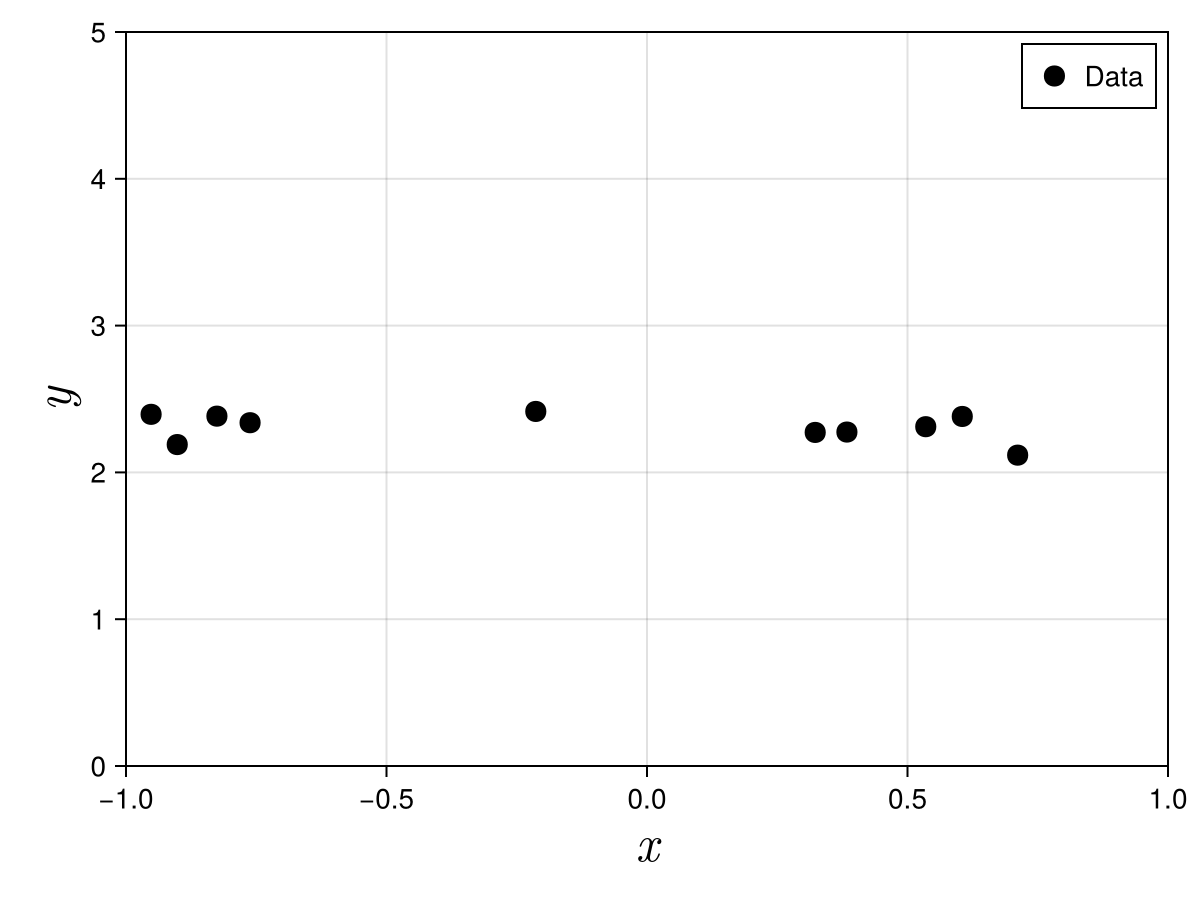

CairoMakie.Screen{IMAGE}


In [11]:
N_SAMPLES=10
rng=Xoshiro(1) #my random number generator

xi=rand(rng,Uniform(-1,1),N_SAMPLES) #generate random values of x between -1 and 1
yi=rand(rng,Normal(2.3,0.1),N_SAMPLES)

fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",
    xlabelsize=25,
    ylabelsize=25,
    limits=(-1,1,0,5),
    backgroundcolor = :transparent)
scatter!(ax,xi,yi;label="Data",color=:black,markersize=15)
axislegend(ax;position = :rt)
save("../figures/04p03ApplicationOfForwardMode.svg",fig)
display(fig)

Define the loss function $S(a_0)=\frac{1}{2}\sum\limits_{i=1}^{N}(y_i-a_0)^2$

In [12]:
S(a0)=0.5*sum((yi.-a0).^2)

S (generic function with 1 method)

For this problem, it is easy to plot and visualise how $S$ changes with $a_0$.  Let's plot $S(a_0)$ for $a_0 \in [0,5]$ 

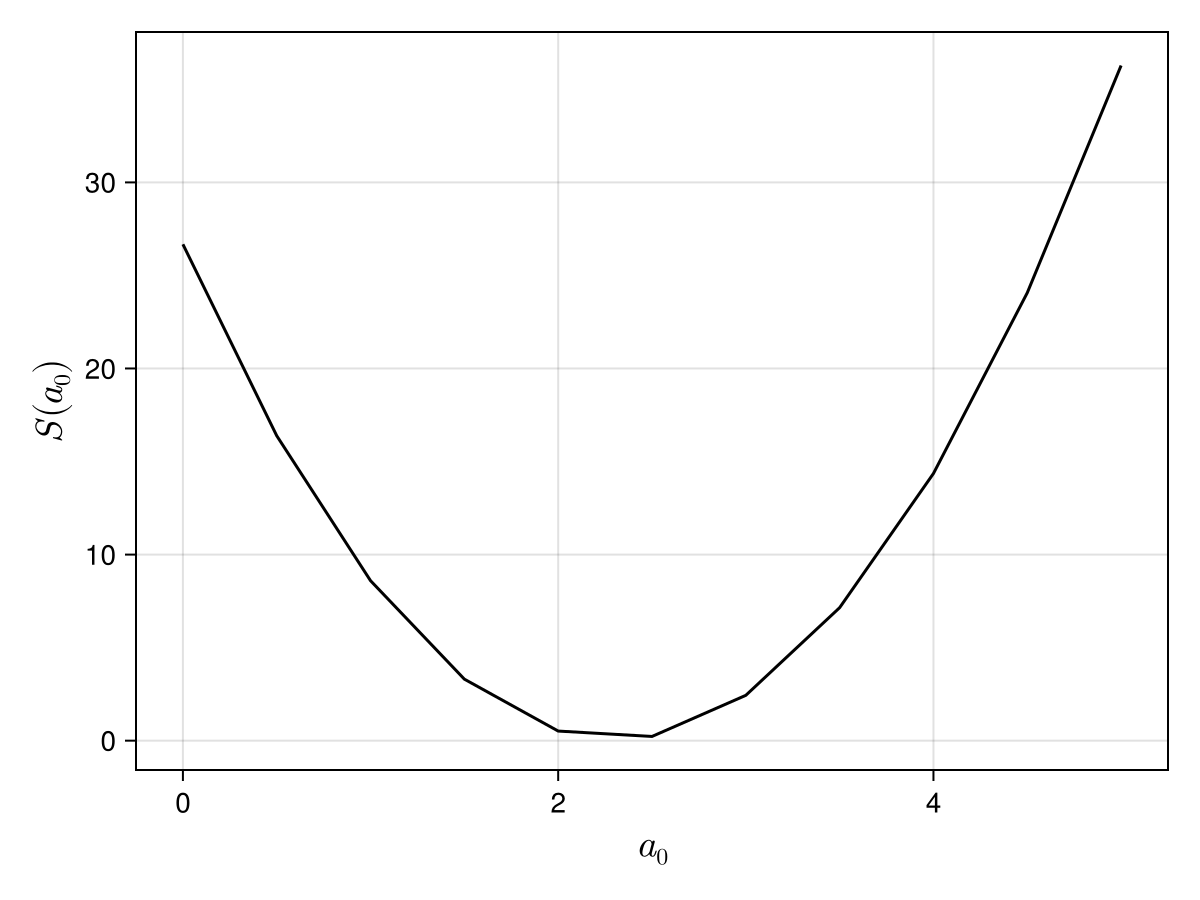

CairoMakie.Screen{IMAGE}


In [13]:
fig = Figure()
a0vec=0:0.5:5
ax = Axis(fig[1, 1], xlabel = L"a_0", ylabel = L"S(a_0)",
    xlabelsize=20,
    ylabelsize=20,
    backgroundcolor = :transparent)
lines!(ax,a0vec,S.(a0vec),color=:black)
save("../figures/04p03ApplicationOfForwardMode02.svg",fig)
display(fig)

Check to see if I can calculate derivative at $a_0=1$

In [14]:
a0=Dual(1.0,1.0)
S(a0).∂

-13.079059040647497

and at $a_0=4$

In [15]:
a0=Dual(4.0,1.0)
S(a0).∂

16.920940959352503

The derivative of $S$ at $a_0=1$ is negative and $a_0=4$ is positive.  This is consistent with the graph above, giving us confidence that everything is working as it should be.

Now we will use gradient descent to find the location of the minimum, starting with $a_0=1.0$.

In [16]:
a0=Dual(1.0,1.0)

α=0.01

for i=1:500
    a0.v=a0.v-α*S(a0).∂
    println(a0.v)
end

1.130790590406475
1.2485021217723025
1.3544425000015472
1.4497888404078674
1.5356005467735556
1.612831082502675
1.6823385646588824
1.7448952985994692
1.8011963591459972
1.8518673136378725
1.8974711726805602
1.9385146458189793
1.9754537716435563
2.0086989848856756
2.038619676803583
2.0655482995297
2.089784059983205
2.1115962443913596
2.1312272103586984
2.1488950797293036
2.1647961621628484
2.1791071363530388
2.19198701312421
2.203578902218264
2.2140116024029126
2.2234010325690963
2.2318515197186617
2.2394569581532706
2.2463018527444185
2.2524622578764517
2.2580066224952815
2.2629965506522285
2.2674874859934806
2.2715293278006077
2.275166985427022
2.2784408772907945
2.28138737996819
2.284039232377846
2.2864258995465363
2.2885738999983576
2.2905071004049966
2.292246980770972
2.2938128731003498
2.29522217619679
2.296490548983586
2.2976320844917026
2.298659466449007
2.2995841102105814
2.300416289595998
2.3011652510428733
2.301839316345061
2.30244597511703
2.302991968011802
2.303483361617096

$a_0$ convergest to a value close to 2.3 which is what we would expect.

---